# CCE Moorings and MITgcm - Profile Temporal Scales Analysis   

**Purpose**: Code for comparing the CCE mooring scale analysis with the profile time series from the MITgcm model.

**Luke Colosi | lcolosi@ucsd.edu**

Force matplotlib plots to display directly within the output cell of the notebook: 

In [1]:
%matplotlib inline

Import python libraries

In [2]:
import sys
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt 
from netCDF4 import Dataset, num2date
from datetime import datetime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import cmocean
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib.lines as mlines
import glob
from matplotlib.ticker import LogLocator

# Set path to access python functions
ROOT = '/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/'
sys.path.append(ROOT + 'AirSeaCoupling/tools/')

#--- Other Functions ---# 
import cartopy_figs as cart
from ocean_analysis import compute_mld

In [3]:
def add_corner_label(ax, pos, label, fontsize=12):
    
    # Place text in lower left corner inside the axes
    ax.text(
        pos[0], pos[1], label,
        transform=ax.transAxes,
        fontsize=fontsize,
        fontweight='normal',
        va='top', ha='left',
        bbox=dict(
            boxstyle='square,pad=0.3',
            facecolor=(1, 1, 1, 0.6),  # faded white fill with alpha=0.6
            edgecolor='black',
            linewidth=1
        )
    )

Set data analysis parameters

In [4]:
# Set processing parameters
option_plot          = 0      # Specifies if supplementary plots are plotted
option_sig           = 1

# Set path to project directory
PATH = "/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/AirSeaCoupling"
PATH_bathy  = ROOT + 'AirSeaCoupling/data/bathymetry/'

# Set plotting parameters 
depth_lim = [0,200]
option_data = 'obs'
option_log = 0 
option_iso = 1
fontsize = 14
plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
    "text.usetex": True,           # Use LaTeX for all text
    "font.family": "serif",        # Optional: match LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: load extra LaTeX packages
})

Load CCE intermediate data and mitgcm time scale analysis data

In [5]:
#-------------------------------------------------------#
# MITgcm Data
#-------------------------------------------------------#
ROOT_mitgcm = "/data/mitgcm/SWOT_MARA_RUN4_LY/temporal"
filename_temp    = PATH + ROOT_mitgcm + "/mitgcm_temp_temporal_scale_data.npz"
filename_sal     = PATH + ROOT_mitgcm + "/mitgcm_sal_temporal_scale_data.npz"
filename_rho     = PATH + ROOT_mitgcm + "/mitgcm_density_temporal_scale_data.npz"
filename_u_along = PATH + ROOT_mitgcm + "/mitgcm_u_along_temporal_scale_data.npz" # "/mitgcm_u_along_temporal_scale_data_bin.npz"
filename_v_cross = PATH + ROOT_mitgcm + "/mitgcm_v_cross_temporal_scale_data.npz" # "/mitgcm_v_cross_temporal_scale_data_bin.npz"

# Load data 
ds_temp   = np.load(filename_temp, allow_pickle=True)
ds_sal = np.load(filename_sal, allow_pickle=True)
ds_rho   = np.load(filename_rho, allow_pickle=True)
ds_u = np.load(filename_u_along, allow_pickle=True)
ds_v = np.load(filename_v_cross, allow_pickle=True)

# Extract data variables
depth_m        = np.abs(ds_temp['depth'])
lon_m          = ds_temp["lon"]
lat_m          = ds_temp["lat"]
f_cpd          = ds_temp["f_cpd"]

#--- Conservative Temperature ---# 
Lt1_temp_m     = ds_temp["Lt1"]          # Units: days
Lt2_temp_m     = ds_temp["Lt2"]
Lt3_temp_m     = ds_temp["Lt3"]

meanTemp_m     = ds_temp["mean_profile"] 
stdmTemp1_m    = ds_temp["stdm1_profile"] 
stdmTemp2_m    = ds_temp["stdm2_profile"] 
stdmTemp3_m    = ds_temp["stdm3_profile"] 

S1_temp_m      = ds_temp["S1"]     
S2_temp_m      = ds_temp["S2"]  
S3_temp_m      = ds_temp["S3"]        

#--- Absolute Salinity ---# 
Lt1_sal_m     = ds_sal["Lt1"]          # Units: days
Lt2_sal_m     = ds_sal["Lt2"]
Lt3_sal_m     = ds_sal["Lt3"]

meanSal_m     = ds_sal["mean_profile"] 
stdmSal1_m    = ds_sal["stdm1_profile"] 
stdmSal2_m    = ds_sal["stdm2_profile"] 
stdmSal3_m    = ds_sal["stdm3_profile"] 

S1_sal_m      = ds_sal["S1"]     
S2_sal_m      = ds_sal["S2"]  
S3_sal_m      = ds_sal["S3"] 

#--- Potential Density ---# 
Lt1_rho_m     = ds_rho["Lt1"]          # Units: days
Lt2_rho_m     = ds_rho["Lt2"]
Lt3_rho_m     = ds_rho["Lt3"]

meanRho_m     = ds_rho["mean_profile"] 
stdmRho1_m    = ds_rho["stdm1_profile"] 
stdmRho2_m    = ds_rho["stdm2_profile"] 
stdmRho3_m    = ds_rho["stdm3_profile"] 

S1_rho_m      = ds_rho["S1"]     
S2_rho_m      = ds_rho["S2"]  
S3_rho_m      = ds_rho["S3"] 


#--- Along-shore Velocity ---# 
Lt1_u_m     = ds_u["Lt1"]          # Units: days
Lt2_u_m     = ds_u["Lt2"]
Lt3_u_m     = ds_u["Lt3"]

meanU_m     = ds_u["mean_profile"] 
stdmU1_m    = ds_u["stdm1_profile"] 
stdmU2_m    = ds_u["stdm2_profile"] 
stdmU3_m    = ds_u["stdm3_profile"] 

S1_u_m      = ds_u["S1"]     
S2_u_m      = ds_u["S2"]  
S3_u_m      = ds_u["S3"] 

#--- Cross-shore Velocity ---# 
Lt1_v_m     = ds_v["Lt1"]          # Units: days
Lt2_v_m     = ds_v["Lt2"]
Lt3_v_m     = ds_v["Lt3"]

meanV_m     = ds_v["mean_profile"] 
stdmV1_m    = ds_v["stdm1_profile"] 
stdmV2_m    = ds_v["stdm2_profile"] 
stdmV3_m    = ds_v["stdm3_profile"] 

S1_v_m      = ds_v["S1"]     
S2_v_m      = ds_v["S2"]  
S3_v_m      = ds_v["S3"] 

#-------------------------------------------------------#
# CCE Scale Analysis Data
#-------------------------------------------------------#
filename_CCE1_CTD = glob.glob(PATH + "/data/CCE/CCE1/CTD/CCE1_CTD_*_scale_data_gridded.npz")
filename_CCE2_CTD = glob.glob(PATH + "/data/CCE/CCE2/CTD/CCE2_CTD_*_scale_data_gridded.npz")
filename_CCE1_ADCP = glob.glob(PATH + "/data/CCE/CCE1/ADCP/CCE1_ADCP_*_scale_data.npz")
filename_CCE2_ADCP = glob.glob(PATH + "/data/CCE/CCE2/ADCP/CCE2_ADCP_*_scale_data.npz")

# Load data 
ds_CCE1_CTD    = np.load(filename_CCE1_CTD[0], allow_pickle=True)
ds_CCE2_CTD    = np.load(filename_CCE2_CTD[0], allow_pickle=True)

ds_CCE1_ADCP   = np.load(filename_CCE1_ADCP[0], allow_pickle=True)
ds_CCE2_ADCP   = np.load(filename_CCE2_ADCP[0], allow_pickle=True)

# Extract data variables

#--- CCE1 ---# 
lon1_nc          = ds_CCE1_CTD["lon"]
lat1             = ds_CCE1_CTD["lat"]
depth1           = ds_CCE1_CTD["depth"]
depth1_adcp      = ds_CCE1_ADCP["depth"]

Lt1_temp         = ds_CCE1_CTD["Lt_temp"]         # Units: days
Lt1_sal          = ds_CCE1_CTD["Lt_sal"]
Lt1_rho          = ds_CCE1_CTD["Lt_rho"]

Lt1_u            = ds_CCE1_ADCP["Lt_u"]         # Units: days
Lt1_v            = ds_CCE1_ADCP["Lt_v"]

meanTemp1         = ds_CCE1_CTD["meanTemp_profile"] 
meanSal1         = ds_CCE1_CTD["meanSal_profile"] 
meanRho1         = ds_CCE1_CTD["meanRho_profile"] 
stdmTemp1         = ds_CCE1_CTD["stdmTemp_profile"] 
stdmSal1         = ds_CCE1_CTD["stdmSal_profile"] 
stdmRho1         = ds_CCE1_CTD["stdmRho_profile"] 

meanU1         = ds_CCE1_ADCP["meanU_profile"] 
meanV1         = ds_CCE1_ADCP["meanV_profile"] 
stdmU1         = ds_CCE1_ADCP["stdmU_profile"] 
stdmV1         = ds_CCE1_ADCP["stdmV_profile"] 

S1_temp         = ds_CCE1_CTD["S_temp"]         # Units: days
S1_sal          = ds_CCE1_CTD["S_sal"]
S1_rho          = ds_CCE1_CTD["S_rho"]
f1_temp         = ds_CCE1_CTD["f_temp"]         # Units: cpd
f1_sal          = ds_CCE1_CTD["f_sal"]
f1_rho          = ds_CCE1_CTD["f_rho"]

#--- CCE2 ---# 
lon2_nc          = ds_CCE2_CTD["lon"]
lat2             = ds_CCE2_CTD["lat"]
depth2           = ds_CCE2_CTD["depth"]
depth2_adcp      = ds_CCE2_ADCP["depth"]

Lt2_temp         = ds_CCE2_CTD["Lt_temp"]         # Units: days
Lt2_sal          = ds_CCE2_CTD["Lt_sal"]
Lt2_rho          = ds_CCE2_CTD["Lt_rho"]

Lt2_u            = ds_CCE2_ADCP["Lt_u"]         # Units: days
Lt2_v            = ds_CCE2_ADCP["Lt_v"]

meanTemp2         = ds_CCE2_CTD["meanTemp_profile"] 
meanSal2         = ds_CCE2_CTD["meanSal_profile"] 
meanRho2         = ds_CCE2_CTD["meanRho_profile"] 
stdmTemp2         = ds_CCE2_CTD["stdmTemp_profile"] 
stdmSal2         = ds_CCE2_CTD["stdmSal_profile"] 
stdmRho2         = ds_CCE2_CTD["stdmRho_profile"] 

meanU2         = ds_CCE2_ADCP["meanU_profile"] 
meanV2         = ds_CCE2_ADCP["meanV_profile"] 
stdmU2         = ds_CCE2_ADCP["stdmU_profile"] 
stdmV2         = ds_CCE2_ADCP["stdmV_profile"] 

S2_temp         = ds_CCE1_CTD["S_temp"]         # Units: days
S2_sal          = ds_CCE1_CTD["S_sal"]
S2_rho          = ds_CCE1_CTD["S_rho"]
f2_temp         = ds_CCE1_CTD["f_temp"]         # Units: cpd
f2_sal          = ds_CCE1_CTD["f_sal"]
f2_rho          = ds_CCE1_CTD["f_rho"]

Mask fill values in model decorrelation

In [6]:
Lt1_temp_m = np.ma.masked_where(Lt1_temp_m == 0, Lt1_temp_m)
Lt2_temp_m = np.ma.masked_where(Lt2_temp_m == 0, Lt2_temp_m)
Lt3_temp_m = np.ma.masked_where(Lt3_temp_m == 0, Lt3_temp_m)

meanTemp_m  = np.ma.masked_where(meanTemp_m == 0, meanTemp_m)
stdmTemp1_m = np.ma.masked_where(stdmTemp1_m == 0, stdmTemp1_m)
stdmTemp2_m = np.ma.masked_where(stdmTemp2_m == 0, stdmTemp2_m)
stdmTemp3_m = np.ma.masked_where(stdmTemp3_m == 0, stdmTemp3_m)

Lt1_sal_m = np.ma.masked_where(Lt1_sal_m == 0, Lt1_sal_m)
Lt2_sal_m = np.ma.masked_where(Lt2_sal_m == 0, Lt2_sal_m)
Lt3_sal_m = np.ma.masked_where(Lt3_sal_m == 0, Lt3_sal_m)

Lt1_rho_m = np.ma.masked_where(Lt1_rho_m == 0, Lt1_rho_m)
Lt2_rho_m = np.ma.masked_where(Lt2_rho_m == 0, Lt2_rho_m)
Lt3_rho_m = np.ma.masked_where(Lt3_rho_m == 0, Lt3_rho_m)

meanRho_m  = np.ma.masked_where(meanRho_m == 0, meanRho_m)
stdmRho1_m = np.ma.masked_where(stdmRho1_m == 0, stdmRho1_m)
stdmRho2_m = np.ma.masked_where(stdmRho2_m == 0, stdmRho2_m)
stdmRho3_m = np.ma.masked_where(stdmRho3_m == 0, stdmRho3_m)

Lt1_u_m = np.ma.masked_where(Lt1_u_m == 0, Lt1_u_m)
Lt2_u_m = np.ma.masked_where(Lt2_u_m == 0, Lt2_u_m)
Lt3_u_m = np.ma.masked_where(Lt3_u_m == 0, Lt3_u_m)

meanU_m  = np.ma.masked_where(meanU_m == 0, meanU_m)
stdmU1_m = np.ma.masked_where(stdmU1_m == 0, stdmU1_m)
stdmU2_m = np.ma.masked_where(stdmU2_m == 0, stdmU2_m)
stdmU3_m = np.ma.masked_where(stdmU3_m == 0, stdmU3_m)

Lt1_v_m = np.ma.masked_where(Lt1_v_m == 0, Lt1_v_m)
Lt2_v_m = np.ma.masked_where(Lt2_v_m == 0, Lt2_v_m)
Lt3_v_m = np.ma.masked_where(Lt3_v_m == 0, Lt3_v_m)

meanV_m  = np.ma.masked_where(meanV_m == 0, meanV_m)
stdmV1_m = np.ma.masked_where(stdmV1_m == 0, stdmV1_m)
stdmV2_m = np.ma.masked_where(stdmV2_m == 0, stdmV2_m)
stdmV3_m = np.ma.masked_where(stdmV3_m == 0, stdmV3_m)

Plot the depth profiles of the model and observed decorrelation scales

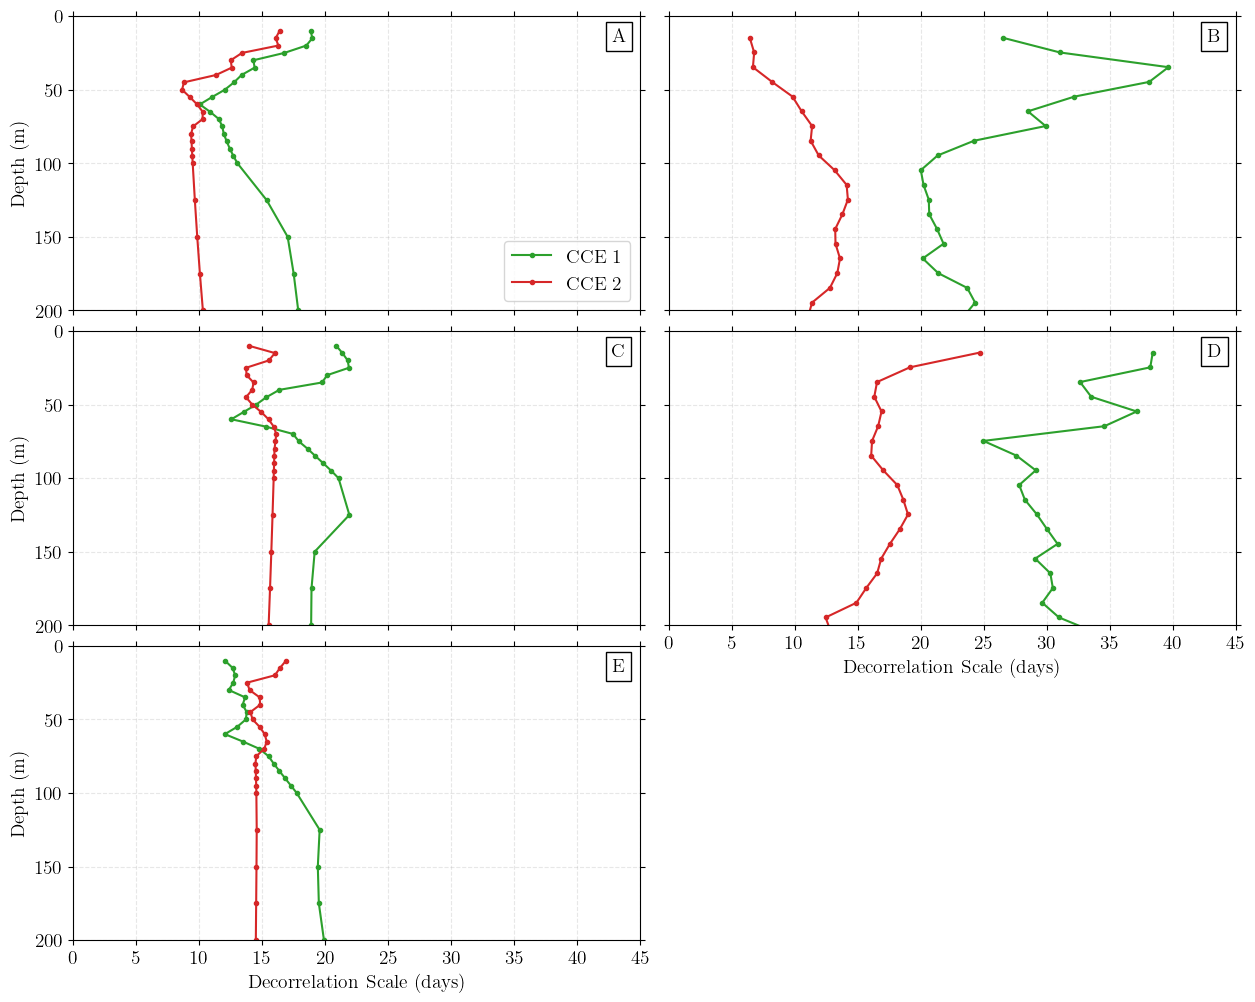

In [7]:
option_data = 'obs'

# Create figure
fig,axes = plt.subplots(3,2,figsize=(15, 12))
ax1,ax2,ax3,ax4,ax5,ax6 = axes.flatten()

#--- Subplot 1 ---# 

# Plot temperature decor scales
if option_data == 'model': 
    ax1.plot(Lt1_temp_m,depth_m,'.-', color='tab:green',label='CCE1')
    ax1.plot(Lt2_temp_m,depth_m,'.-', color='tab:red',label='CCE 2')
    ax1.plot(Lt3_temp_m,depth_m,'.-', color='tab:blue',label='CCE 3')
else: 
    ax1.plot(Lt1_temp,depth1,'.-', color='tab:green',label='CCE 1')
    ax1.plot(Lt2_temp,depth2,'.-', color='tab:red',label='CCE 2')

# Set axis attributes
ax1.set_ylabel("Depth (m)")
ax1.set_xticklabels([])
ax1.set_xlim(0,45)
ax1.set_ylim(depth_lim[0], depth_lim[1])
if option_log == 1: 
    ax1.set_yscale('log')
ax1.invert_yaxis()
ax1.legend(loc='lower right')
ax1.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax1.grid(True,linestyle='--',alpha=0.3)

#--- Subplot 2 ---# 

# Plot absolute salinity decor scales
if option_data == 'model': 
    ax3.plot(Lt1_sal_m,depth_m,'.-', color='tab:green')
    ax3.plot(Lt2_sal_m,depth_m,'.-', color='tab:red')
    ax3.plot(Lt3_sal_m,depth_m,'.-', color='tab:blue')
else: 
    ax3.plot(Lt1_sal,depth1,'.-', color='tab:green')
    ax3.plot(Lt2_sal,depth2,'.-', color='tab:red')

# Set axis attributes
ax3.set_ylabel("Depth (m)")
ax3.set_xticklabels([])
ax3.set_xlim(0,45)
ax3.set_ylim(depth_lim[0], depth_lim[1])
if option_log == 1: 
    ax3.set_yscale('log')
ax3.invert_yaxis()
ax3.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax3.grid(True,linestyle='--',alpha=0.3)

#--- Subplot 3 ---# 

# Plot potential density decor scales
if option_data == 'model': 
    ax5.plot(Lt1_rho_m,depth_m,'.-', color='tab:green')
    ax5.plot(Lt2_rho_m,depth_m,'.-', color='tab:red')
    ax5.plot(Lt3_rho_m,depth_m,'.-', color='tab:blue')
else: 
    ax5.plot(Lt1_rho,depth1,'.-', color='tab:green')
    ax5.plot(Lt2_rho,depth2,'.-', color='tab:red')

# Set axis attributes
ax5.set_xlabel(r'Decorrelation Scale (days)')
ax5.set_ylabel("Depth (m)")
ax5.set_xlim(0,45)
ax5.set_ylim(depth_lim[0], depth_lim[1])
if option_log == 1: 
    ax5.set_yscale('log')
ax5.invert_yaxis()
ax5.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax5.grid(True,linestyle='--',alpha=0.3)

#--- Subplot 4 ---# 

# Plot along-shelf velocity decor scales
if option_data == 'model': 
    ax4.plot(Lt1_u_m,depth_m,'.-', color='tab:green')
    ax4.plot(Lt2_u_m,depth_m,'.-', color='tab:red')
    ax4.plot(Lt3_u_m,depth_m,'.-', color='tab:blue')
else: 
    ax4.plot(Lt1_u,depth1_adcp,'.-', color='tab:green')
    ax4.plot(Lt2_u,depth2_adcp,'.-', color='tab:red')

# Set axis attributes
ax4.set_xlabel(r'Decorrelation Scale (days)')
ax4.set_yticklabels([])
ax4.set_xlim(0,45) # ax4.set_xlim(0,100)
ax4.set_ylim(depth_lim[0], depth_lim[1])
if option_log == 1: 
    ax4.set_yscale('log')
ax4.invert_yaxis()
ax4.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax4.grid(True,linestyle='--',alpha=0.3)

#--- Subplot 5 ---# 

# Plot Cross-shelf decor scales
if option_data == 'model': 
    ax2.plot(Lt1_v_m,depth_m,'.-', color='tab:green')
    ax2.plot(Lt2_v_m,depth_m,'.-', color='tab:red')
    ax2.plot(Lt3_v_m,depth_m,'.-', color='tab:blue')
else: 
    ax2.plot(Lt1_v,depth1_adcp,'.-', color='tab:green')
    ax2.plot(Lt2_v,depth2_adcp,'.-', color='tab:red')

# Set axis attributes
ax2.set_xticklabels([])
ax2.set_yticklabels([])
ax2.set_xlim(0,45) #ax4.set_xlim(0,100)
ax2.set_ylim(depth_lim[0], depth_lim[1])
if option_log == 1: 
    ax2.set_yscale('log')
ax2.invert_yaxis()
ax2.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax2.grid(True,linestyle='--',alpha=0.3)

#--- Subplot 5 ---# 
ax6.axis('off')

# Label each subplot
pos = [0.95, 0.96]
add_corner_label(ax1, pos, 'A', fontsize = fontsize)
add_corner_label(ax2, pos, 'B', fontsize = fontsize)
add_corner_label(ax3, pos, 'C', fontsize = fontsize)
add_corner_label(ax4, pos, 'D', fontsize = fontsize)
add_corner_label(ax5, pos, 'E', fontsize = fontsize)

# Show figure
plt.subplots_adjust(hspace=0.07, wspace=0.05)
plt.show()

Plot the mean profile next to each depth profile of decorrelation scale

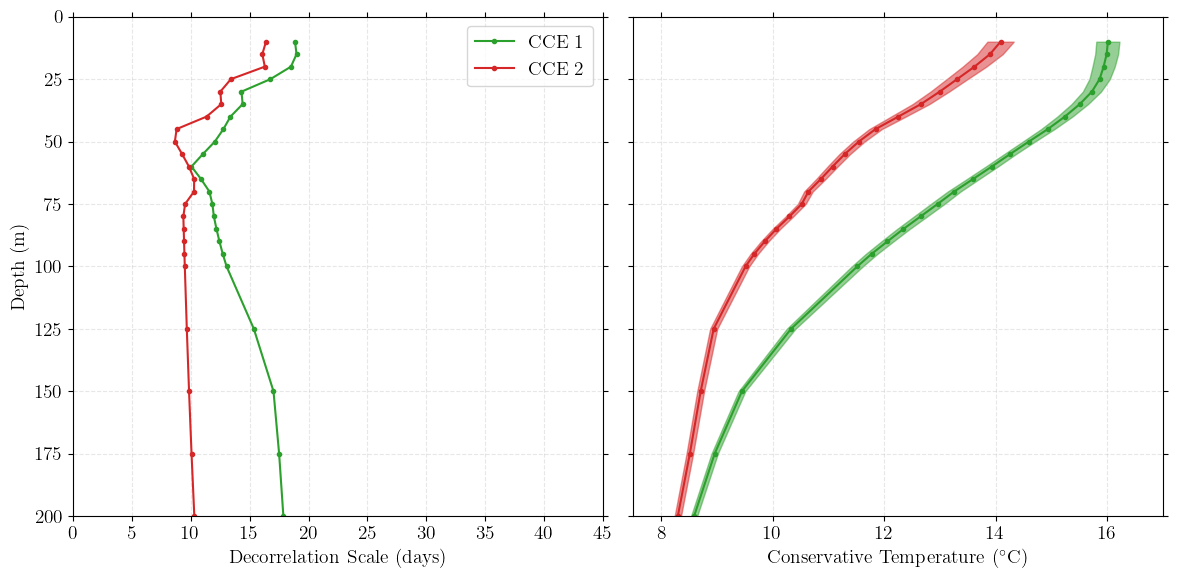

In [8]:
# Create figure
fig, axes = plt.subplots(1,2,figsize=(12, 6))
ax1, ax2 = axes.flatten()

#--- Subplot 1 ---# 

# Plot temperature decor scales
if option_data == 'model': 
    ax1.plot(Lt1_temp_m,depth_m,'.-', color='tab:green',label='CCE1')
    ax1.plot(Lt2_temp_m,depth_m,'.-', color='tab:red',label='CCE 2')
    ax1.plot(Lt3_temp_m,depth_m,'.-', color='tab:blue',label='CCE 3')
else: 
    ax1.plot(Lt1_temp,depth1,'.-', color='tab:green',label='CCE 1')
    ax1.plot(Lt2_temp,depth2,'.-', color='tab:red',label='CCE 2')

# Set axis attributes
ax1.set_xlabel(r'Decorrelation Scale (days)')
ax1.set_ylabel("Depth (m)")
ax1.set_xlim(0,45)
ax1.set_ylim(depth_lim[0], depth_lim[1])
if option_log == 1: 
    ax1.set_yscale('log')
ax1.invert_yaxis()
ax1.legend()
ax1.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax1.grid(True,linestyle='--',alpha=0.3)

#--- Subplot 2 ---# 

if option_data == 'model': 

    # Plot mean profiles for each mooring
    ax2.plot(meanTemp_m[0,:],abs(depth_m),'.-',color='tab:green',label='CCE 1')
    ax2.plot(meanTemp_m[1,:],abs(depth_m),'.-',color='tab:red',label='CCE 2')
    ax2.plot(meanTemp_m[2,:],abs(depth_m),'.-',color='tab:blue',label='CCE 3')

    # Plot standard error of the mean profiles for each mooring
    ax2.fill_betweenx(abs(depth_m), meanTemp_m[0,:] - stdmTemp1_m, meanTemp_m[0,:] + stdmTemp1_m, color='tab:green', alpha=0.5)
    ax2.fill_betweenx(abs(depth_m), meanTemp_m[1,:] - stdmTemp2_m, meanTemp_m[1,:] + stdmTemp2_m, color='tab:red', alpha=0.5)
    ax2.fill_betweenx(abs(depth_m), meanTemp_m[2,:] - stdmTemp3_m, meanTemp_m[2,:] + stdmTemp3_m, color='tab:blue', alpha=0.5)

else: 

    # Plot mean profiles for each mooring
    ax2.plot(meanTemp1,abs(depth1),'.-',color='tab:green',label='CCE 1')
    ax2.plot(meanTemp2,abs(depth2),'.-',color='tab:red',label='CCE 2')

    # Plot standard error of the mean profiles for each mooring
    ax2.fill_betweenx(abs(depth1), meanTemp1 - stdmTemp1, meanTemp1 + stdmTemp1, color='tab:green', alpha=0.5)
    ax2.fill_betweenx(abs(depth2), meanTemp2 - stdmTemp2, meanTemp2 + stdmTemp2, color='tab:red', alpha=0.5)


# Set axis attributes
ax2.set_xlabel(r'Conservative Temperature ($^\circ$C)')
ax2.set_yticklabels([])
if option_log == 1: 
    ax1.set_yscale('log')
ax2.set_xlim(7.5,17)
ax2.set_ylim(0,200)
ax2.invert_yaxis()
ax2.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax2.grid(True,linestyle='--',alpha=0.3)

# Show figure
plt.tight_layout()
plt.show()

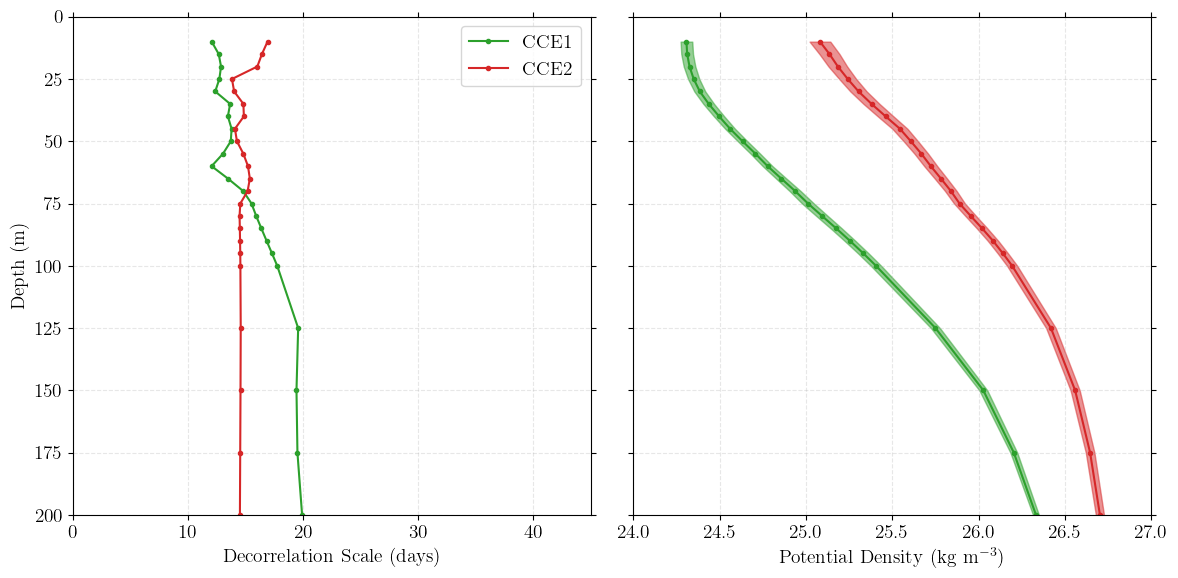

In [9]:
# Create figure
fig, axes = plt.subplots(1,2,figsize=(12, 6))
ax1, ax2 = axes.flatten()

#--- Subplot 1 ---# 

# Plot potential density decor scales
if option_data == 'model': 
    ax1.plot(Lt1_rho_m,depth_m,'.-', color='tab:green',label='CCE1')
    ax1.plot(Lt2_rho_m,depth_m,'.-', color='tab:red',label='CCE2')
    ax1.plot(Lt3_rho_m,depth_m,'.-', color='tab:blue',label='CCE3')
else: 
    ax1.plot(Lt1_rho,depth1,'.-', color='tab:green',label='CCE1')
    ax1.plot(Lt2_rho,depth2,'.-', color='tab:red',label='CCE2')

# Set axis attributes
ax1.set_xlabel(r'Decorrelation Scale (days)')
ax1.set_ylabel("Depth (m)")
ax1.set_xlim(0,45)
ax1.set_ylim(depth_lim[0], depth_lim[1])
if option_log == 1: 
    ax1.set_yscale('log')
ax1.invert_yaxis()
ax1.legend()
ax1.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax1.grid(True,linestyle='--',alpha=0.3)

#--- Subplot 2 ---# 

if option_data == 'model': 

    # Plot mean profiles for each mooring
    ax2.plot(meanRho_m[0,:],abs(depth_m),'.-',color='tab:green',label='CCE 1')
    ax2.plot(meanRho_m[1,:],abs(depth_m),'.-',color='tab:red',label='CCE 2')
    ax2.plot(meanRho_m[2,:],abs(depth_m),'.-',color='tab:blue',label='CCE 3')

    # Plot standard error of the mean profiles for each mooring
    ax2.fill_betweenx(abs(depth_m), meanRho_m[0,:] - stdmRho1_m, meanRho_m[0,:] + stdmRho1_m, color='tab:green', alpha=0.5)
    ax2.fill_betweenx(abs(depth_m), meanRho_m[1,:] - stdmRho2_m, meanRho_m[1,:] + stdmRho2_m, color='tab:red', alpha=0.5)
    ax2.fill_betweenx(abs(depth_m), meanRho_m[2,:] - stdmRho3_m, meanRho_m[2,:] + stdmRho3_m, color='tab:blue', alpha=0.5)

else: 

    # Plot mean profiles for each mooring
    ax2.plot(meanRho1,abs(depth1),'.-',color='tab:green',label='CCE 1')
    ax2.plot(meanRho2,abs(depth2),'.-',color='tab:red',label='CCE 2')

    # Plot standard error of the mean profiles for each mooring
    ax2.fill_betweenx(abs(depth1), meanRho1 - stdmRho1, meanRho1 + stdmRho1, color='tab:green', alpha=0.5)
    ax2.fill_betweenx(abs(depth2), meanRho2 - stdmRho2, meanRho2 + stdmRho2, color='tab:red', alpha=0.5)

# Set axis attributes
ax2.set_xlabel(r'Potential Density (kg m$^{-3}$)')
ax2.set_yticklabels([])
if option_log == 1: 
    ax1.set_yscale('log')
ax2.set_xlim(24,27)
ax2.set_ylim(0,200)
ax2.invert_yaxis()
ax2.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax2.grid(True,linestyle='--',alpha=0.3)

# Show figure
plt.tight_layout()
plt.show()

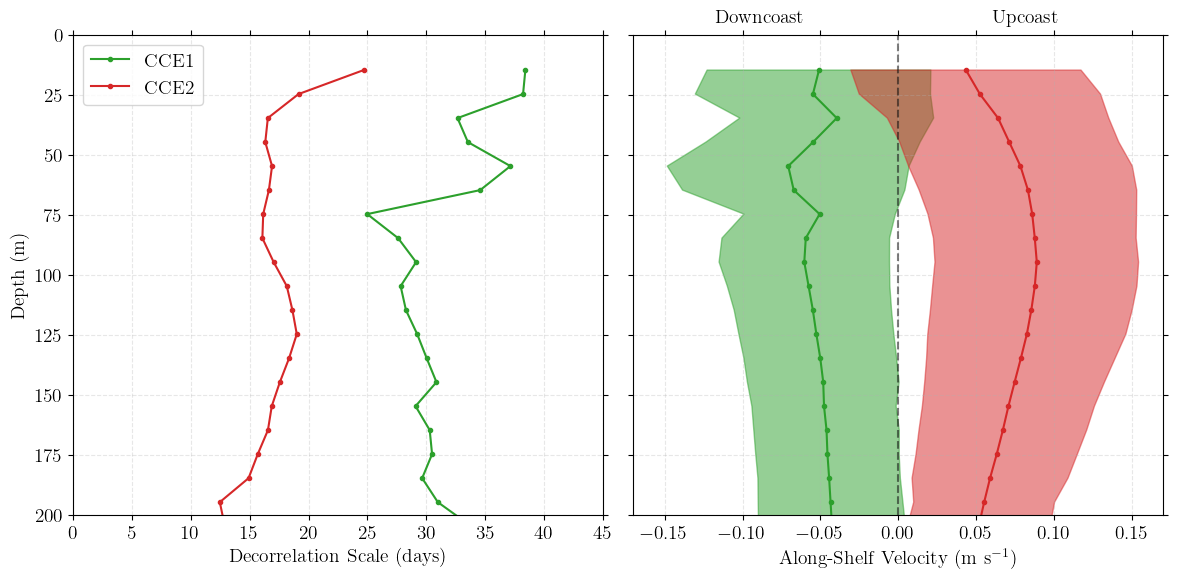

In [10]:
# Create figure
fig, axes = plt.subplots(1,2,figsize=(12, 6))
ax1, ax2 = axes.flatten()

#--- Subplot 1 ---# 

# Plot along-shelf velocity decor scales
if option_data == 'model': 
    ax1.plot(Lt1_u_m,depth_m,'.-', color='tab:green',label='CCE1')
    ax1.plot(Lt2_u_m,depth_m,'.-', color='tab:red',label='CCE2')
    ax1.plot(Lt3_u_m,depth_m,'.-', color='tab:blue',label='CCE3')
else: 
    ax1.plot(Lt1_u,depth1_adcp,'.-', color='tab:green',label='CCE1')
    ax1.plot(Lt2_u,depth2_adcp,'.-', color='tab:red',label='CCE2')

# Set axis attributes
ax1.set_xlabel(r'Decorrelation Scale (days)')
ax1.set_ylabel("Depth (m)")
ax1.set_xlim(0,45)
ax1.set_ylim(depth_lim[0], depth_lim[1])
if option_log == 1: 
    ax1.set_yscale('log')
ax1.invert_yaxis()
ax1.legend()
ax1.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax1.grid(True,linestyle='--',alpha=0.3)

#--- Subplot 2 ---# 

if option_data == 'model': 

    # Plot mean profiles for each mooring
    ax2.plot(meanU_m[0,:],abs(depth_m),'.-',color='tab:green',label='CCE 1')
    ax2.plot(meanU_m[1,:],abs(depth_m),'.-',color='tab:red',label='CCE 2')
    ax2.plot(meanU_m[2,:],abs(depth_m),'.-',color='tab:blue',label='CCE 3')

    # Plot standard error of the mean profiles for each mooring
    ax2.fill_betweenx(abs(depth_m), meanU_m[0,:] - stdmU1_m, meanU_m[0,:] + stdmU1_m, color='tab:green', alpha=0.5)
    ax2.fill_betweenx(abs(depth_m), meanU_m[1,:] - stdmU2_m, meanU_m[1,:] + stdmU2_m, color='tab:red', alpha=0.5)
    ax2.fill_betweenx(abs(depth_m), meanU_m[2,:] - stdmU3_m, meanU_m[2,:] + stdmU3_m, color='tab:blue', alpha=0.5)

    # Plot vertical line for the zero crossing
    ax2.axvline(0,linestyle='--', color='k', alpha = 0.5)

else: 

    # Plot mean profiles for each mooring
    ax2.plot(meanU1,abs(depth1_adcp),'.-',color='tab:green',label='CCE 1')
    ax2.plot(meanU2,abs(depth2_adcp),'.-',color='tab:red',label='CCE 2')

    # Plot standard error of the mean profiles for each mooring
    ax2.fill_betweenx(abs(depth1_adcp), meanU1 - stdmU1, meanU1 + stdmU1, color='tab:green', alpha=0.5)
    ax2.fill_betweenx(abs(depth2_adcp), meanU2 - stdmU2, meanU2 + stdmU2, color='tab:red', alpha=0.5)

    # Plot vertical line for the zero crossing
    ax2.axvline(0,linestyle='--', color='k', alpha = 0.5)

# Set axis attributes
ax2.set_xlabel(r'Along-Shelf Velocity (m s$^{-1}$)')
ax2.set_yticklabels([])
if option_log == 1: 
    ax1.set_yscale('log')
ax2.set_xlim(-0.17,0.17)
ax2.set_ylim(0,200)
ax2.invert_yaxis()
ax2.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax2.grid(True,linestyle='--',alpha=0.3)

# Add text for upcoast/downcoast
x_pos, y_pos = 0.05, -7
ax2.text(x_pos + 0.01, y_pos, 'Upcoast', va='center', ha='left')
ax2.text(-x_pos - 0.01, y_pos, 'Downcoast', va='center', ha='right')

# Show figure
plt.tight_layout()
plt.show()

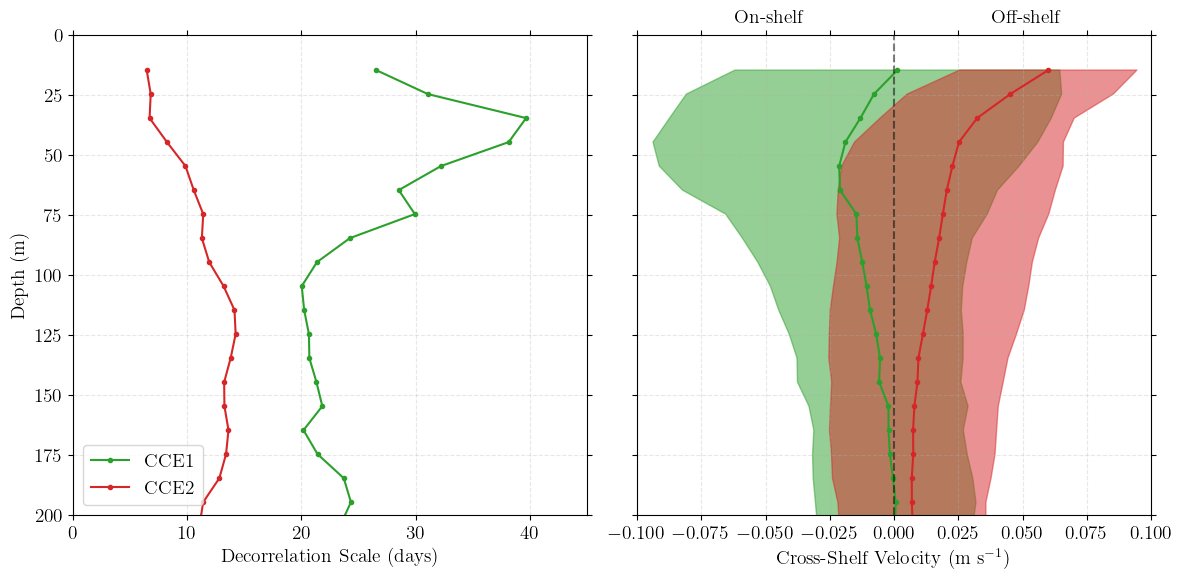

In [11]:
# Create figure
fig, axes = plt.subplots(1,2,figsize=(12, 6))
ax1, ax2 = axes.flatten()

option_data = 'obs'

#--- Subplot 1 ---# 

# Plot potential density decor scales
if option_data == 'model': 
    ax1.plot(Lt1_v_m,depth_m,'.-', color='tab:green',label='CCE1')
    ax1.plot(Lt2_v_m,depth_m,'.-', color='tab:red',label='CCE2')
    ax1.plot(Lt3_v_m,depth_m,'.-', color='tab:blue',label='CCE3')
else: 
    ax1.plot(Lt1_v,depth1_adcp,'.-', color='tab:green',label='CCE1')
    ax1.plot(Lt2_v,depth2_adcp,'.-', color='tab:red',label='CCE2')

# Set axis attributes
ax1.set_xlabel(r'Decorrelation Scale (days)')
ax1.set_ylabel("Depth (m)")
ax1.set_xlim(0,45)
ax1.set_ylim(depth_lim[0], depth_lim[1])
if option_log == 1: 
    ax1.set_yscale('log')
ax1.invert_yaxis()
ax1.legend()
ax1.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax1.grid(True,linestyle='--',alpha=0.3)

#--- Subplot 2 ---# 

if option_data == 'model': 

    # Plot mean profiles for each mooring
    ax2.plot(meanV_m[0,:],abs(depth_m),'.-',color='tab:green',label='CCE 1')
    ax2.plot(meanV_m[1,:],abs(depth_m),'.-',color='tab:red',label='CCE 2')
    ax2.plot(meanV_m[2,:],abs(depth_m),'.-',color='tab:blue',label='CCE 3')

    # Plot standard error of the mean profiles for each mooring
    ax2.fill_betweenx(abs(depth_m), meanV_m[0,:] - stdmV1_m, meanV_m[0,:] + stdmV1_m, color='tab:green', alpha=0.5)
    ax2.fill_betweenx(abs(depth_m), meanV_m[1,:] - stdmV2_m, meanV_m[1,:] + stdmV2_m, color='tab:red', alpha=0.5)
    ax2.fill_betweenx(abs(depth_m), meanV_m[2,:] - stdmV3_m, meanV_m[2,:] + stdmV3_m, color='tab:blue', alpha=0.5)

    # Plot vertical line for the zero crossing
    ax2.axvline(0,linestyle='--', color='k', alpha = 0.5)

else: 

    # Plot mean profiles for each mooring
    ax2.plot(meanV1,abs(depth1_adcp),'.-',color='tab:green',label='CCE 1')
    ax2.plot(meanV2,abs(depth2_adcp),'.-',color='tab:red',label='CCE 2')

    # Plot standard error of the mean profiles for each mooring
    ax2.fill_betweenx(abs(depth1_adcp), meanV1 - stdmV1, meanV1 + stdmV1, color='tab:green', alpha=0.5)
    ax2.fill_betweenx(abs(depth2_adcp), meanV2 - stdmV2, meanV2 + stdmV2, color='tab:red', alpha=0.5)

    # Plot vertical line for the zero crossing
    ax2.axvline(0,linestyle='--', color='k', alpha = 0.5)

# Set axis attributes
ax2.set_xlabel(r'Cross-Shelf Velocity (m s$^{-1}$)')
ax2.set_yticklabels([])
if option_log == 1: 
    ax1.set_yscale('log')
ax2.set_xlim(-0.10,0.10)
ax2.set_ylim(0,200)
ax2.invert_yaxis()
ax2.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax2.grid(True,linestyle='--',alpha=0.3)

# Add text for upcoast/downcoast
x_pos, y_pos = 0.05, -7
ax2.text(x_pos - 0.012, y_pos, 'Off-shelf', va='center', ha='left')
ax2.text(-x_pos + 0.015, y_pos, 'On-shelf', va='center', ha='right')

# Show figure
plt.tight_layout()
plt.show()

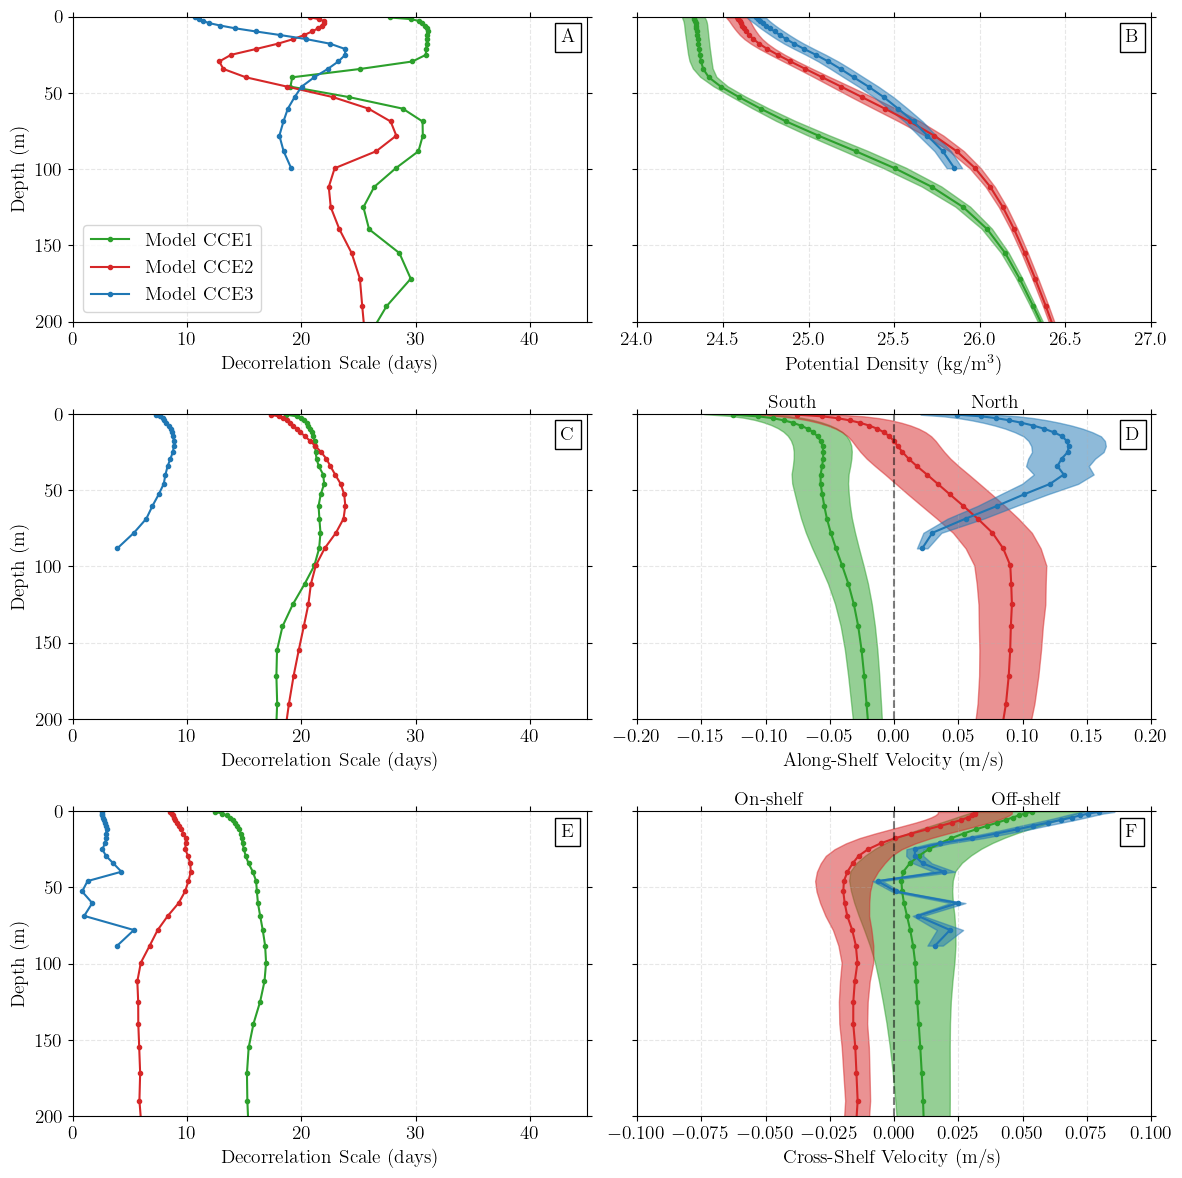

In [12]:
# Set Parameters
option_data = 'model'

# Create figure
fig, axes = plt.subplots(3,2,figsize=(12, 12))
ax1, ax2, ax3, ax4, ax5, ax6 = axes.flatten()

#--- Subplot 1 ---# 

# Plot potential density decor scales
if option_data == 'model': 
    ax1.plot(Lt1_rho_m,depth_m,'.-', color='tab:green',label='Model CCE1')
    ax1.plot(Lt2_rho_m,depth_m,'.-', color='tab:red',label='Model CCE2')
    ax1.plot(Lt3_rho_m,depth_m,'.-', color='tab:blue',label='Model CCE3')
else: 
    ax1.plot(Lt1_rho,depth1,'.-', color='tab:green',label='CCE1')
    ax1.plot(Lt2_rho,depth2,'.-', color='tab:red',label='CCE2')

# Set axis attributes
ax1.set_xlabel(r'Decorrelation Scale (days)')
ax1.set_ylabel("Depth (m)")
ax1.set_xlim(0,45)
ax1.set_ylim(depth_lim[0], depth_lim[1])
if option_log == 1: 
    ax1.set_yscale('log')
ax1.invert_yaxis()
ax1.legend()
ax1.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax1.grid(True,linestyle='--',alpha=0.3)

#--- Subplot 2 ---# 

if option_data == 'model': 

    # Plot mean profiles for each mooring
    ax2.plot(meanRho_m[0,:],abs(depth_m),'.-',color='tab:green',label='CCE 1')
    ax2.plot(meanRho_m[1,:],abs(depth_m),'.-',color='tab:red',label='CCE 2')
    ax2.plot(meanRho_m[2,:],abs(depth_m),'.-',color='tab:blue',label='CCE 3')

    # Plot standard error of the mean profiles for each mooring
    ax2.fill_betweenx(abs(depth_m), meanRho_m[0,:] - stdmRho1_m, meanRho_m[0,:] + stdmRho1_m, color='tab:green', alpha=0.5)
    ax2.fill_betweenx(abs(depth_m), meanRho_m[1,:] - stdmRho2_m, meanRho_m[1,:] + stdmRho2_m, color='tab:red', alpha=0.5)
    ax2.fill_betweenx(abs(depth_m), meanRho_m[2,:] - stdmRho3_m, meanRho_m[2,:] + stdmRho3_m, color='tab:blue', alpha=0.5)

else: 

    # Plot mean profiles for each mooring
    ax2.plot(meanRho1,abs(depth1),'.-',color='tab:green',label='CCE 1')
    ax2.plot(meanRho2,abs(depth2),'.-',color='tab:red',label='CCE 2')

    # Plot standard error of the mean profiles for each mooring
    ax2.fill_betweenx(abs(depth1), meanRho1 - stdmRho1, meanRho1 + stdmRho1, color='tab:green', alpha=0.5)
    ax2.fill_betweenx(abs(depth2), meanRho2 - stdmRho2, meanRho2 + stdmRho2, color='tab:red', alpha=0.5)

# Set axis attributes
ax2.set_xlabel(r'Potential Density (kg/m$^3$)')
ax2.set_yticklabels([])
if option_log == 1: 
    ax1.set_yscale('log')
ax2.set_xlim(24,27)
ax2.set_ylim(0,200)
ax2.invert_yaxis()
ax2.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax2.grid(True,linestyle='--',alpha=0.3)

#--- Subplot 3 ---# 

# Plot along-shelf velocity decor scales
if option_data == 'model': 
    ax3.plot(Lt1_u_m,depth_m,'.-', color='tab:green')
    ax3.plot(Lt2_u_m,depth_m,'.-', color='tab:red')
    ax3.plot(Lt3_u_m,depth_m,'.-', color='tab:blue')
else: 
    ax3.plot(Lt1_u,depth1_adcp,'.-', color='tab:green')
    ax3.plot(Lt2_u,depth2_adcp,'.-', color='tab:red')

# Set axis attributes
ax3.set_xlabel(r'Decorrelation Scale (days)')
ax3.set_ylabel("Depth (m)")
ax3.set_xlim(0,45) #ax4.set_xlim(0,100)
ax3.set_ylim(depth_lim[0], depth_lim[1])
if option_log == 1: 
    ax3.set_yscale('log')
ax3.invert_yaxis()
ax3.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax3.grid(True,linestyle='--',alpha=0.3)

#--- Subplot 4 ---# 

if option_data == 'model': 

    # Plot mean profiles for each mooring
    ax4.plot(meanU_m[0,:],abs(depth_m),'.-',color='tab:green')
    ax4.plot(meanU_m[1,:],abs(depth_m),'.-',color='tab:red')
    ax4.plot(meanU_m[2,:],abs(depth_m),'.-',color='tab:blue')

    # Plot standard error of the mean profiles for each mooring
    ax4.fill_betweenx(abs(depth_m), meanU_m[0,:] - stdmU1_m, meanU_m[0,:] + stdmU1_m, color='tab:green', alpha=0.5)
    ax4.fill_betweenx(abs(depth_m), meanU_m[1,:] - stdmU2_m, meanU_m[1,:] + stdmU2_m, color='tab:red', alpha=0.5)
    ax4.fill_betweenx(abs(depth_m), meanU_m[2,:] - stdmU3_m, meanU_m[2,:] + stdmU3_m, color='tab:blue', alpha=0.5)

    # Plot vertical line for the zero crossing
    ax4.axvline(0,linestyle='--', color='k', alpha = 0.5)

else: 

    # Plot mean profiles for each mooring
    ax4.plot(meanU1,abs(depth1_adcp),'.-',color='tab:green')
    ax4.plot(meanU2,abs(depth2_adcp),'.-',color='tab:red')

    # Plot standard error of the mean profiles for each mooring
    ax4.fill_betweenx(abs(depth1_adcp), meanU1 - stdmU1, meanU1 + stdmU1, color='tab:green', alpha=0.5)
    ax4.fill_betweenx(abs(depth2_adcp), meanU2 - stdmU2, meanU2 + stdmU2, color='tab:red', alpha=0.5)

    # Plot vertical line for the zero crossing
    ax4.axvline(0,linestyle='--', color='k', alpha = 0.5)

# Set axis attributes
ax4.set_xlabel(r'Along-Shelf Velocity (m/s)')
ax4.set_yticklabels([])
if option_log == 1: 
    ax4.set_yscale('log')
ax4.set_xlim(-0.20,0.20) # ax4.set_xlim(-0.30,0.30)
ax4.set_ylim(0,200)
ax4.invert_yaxis()
ax4.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax4.grid(True,linestyle='--',alpha=0.3)

# Add text for upcoast/downcoast
x_pos, y_pos = 0.05, -7
ax4.text(x_pos + 0.01, y_pos, 'North', va='center', ha='left')
ax4.text(-x_pos - 0.01, y_pos, 'South', va='center', ha='right')

#--- Subplot 5 ---# 

# Plot potential density decor scales
if option_data == 'model': 
    ax5.plot(Lt1_v_m,depth_m,'.-', color='tab:green')
    ax5.plot(Lt2_v_m,depth_m,'.-', color='tab:red')
    ax5.plot(Lt3_v_m,depth_m,'.-', color='tab:blue')
else: 
    ax5.plot(Lt1_v,depth1_adcp,'.-', color='tab:green')
    ax5.plot(Lt2_v,depth2_adcp,'.-', color='tab:red')

# Set axis attributes
ax5.set_xlabel(r'Decorrelation Scale (days)')
ax5.set_ylabel("Depth (m)")
ax5.set_xlim(0,45) # ax4.set_xlim(0,100)
ax5.set_ylim(depth_lim[0], depth_lim[1])
if option_log == 1: 
    ax5.set_yscale('log')
ax5.invert_yaxis()
ax5.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax5.grid(True,linestyle='--',alpha=0.3)

#--- Subplot 6 ---# 

if option_data == 'model': 

    # Plot mean profiles for each mooring
    ax6.plot(meanV_m[0,:],abs(depth_m),'.-',color='tab:green')
    ax6.plot(meanV_m[1,:],abs(depth_m),'.-',color='tab:red')
    ax6.plot(meanV_m[2,:],abs(depth_m),'.-',color='tab:blue')

    # Plot standard error of the mean profiles for each mooring
    ax6.fill_betweenx(abs(depth_m), meanV_m[0,:] - stdmV1_m, meanV_m[0,:] + stdmV1_m, color='tab:green', alpha=0.5)
    ax6.fill_betweenx(abs(depth_m), meanV_m[1,:] - stdmV2_m, meanV_m[1,:] + stdmV2_m, color='tab:red', alpha=0.5)
    ax6.fill_betweenx(abs(depth_m), meanV_m[2,:] - stdmV3_m, meanV_m[2,:] + stdmV3_m, color='tab:blue', alpha=0.5)

    # Plot vertical line for the zero crossing
    ax6.axvline(0,linestyle='--', color='k', alpha = 0.5)

else: 

    # Plot mean profiles for each mooring
    ax6.plot(meanV1,abs(depth1_adcp),'.-',color='tab:green')
    ax6.plot(meanV2,abs(depth2_adcp),'.-',color='tab:red')

    # Plot standard error of the mean profiles for each mooring
    ax6.fill_betweenx(abs(depth1_adcp), meanV1 - stdmV1, meanV1 + stdmV1, color='tab:green', alpha=0.5)
    ax6.fill_betweenx(abs(depth2_adcp), meanV2 - stdmV2, meanV2 + stdmV2, color='tab:red', alpha=0.5)

    # Plot vertical line for the zero crossing
    ax6.axvline(0,linestyle='--', color='k', alpha = 0.5)

# Set axis attributes
ax6.set_xlabel(r'Cross-Shelf Velocity (m/s)')
ax6.set_yticklabels([])
if option_log == 1: 
    ax6.set_yscale('log')
ax6.set_xlim(-0.10,0.10) # ax6.set_xlim(-0.20,0.20)
ax6.set_ylim(0,200)
ax6.invert_yaxis()
ax6.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax6.grid(True,linestyle='--',alpha=0.3)

# Add text for upcoast/downcoast
x_pos, y_pos = 0.05, -7
ax6.text(x_pos - 0.012, y_pos, 'Off-shelf', va='center', ha='left')
ax6.text(-x_pos + 0.015, y_pos, 'On-shelf', va='center', ha='right')

# Label each subplot
pos = [0.95, 0.96]
add_corner_label(ax1, pos, 'A', fontsize = fontsize)
add_corner_label(ax2, pos, 'B', fontsize = fontsize)
add_corner_label(ax3, pos, 'C', fontsize = fontsize)
add_corner_label(ax4, pos, 'D', fontsize = fontsize)
add_corner_label(ax5, pos, 'E', fontsize = fontsize)
add_corner_label(ax6, pos, 'F', fontsize = fontsize)

# Show figure
plt.tight_layout()
plt.show()

In [13]:
# Multiply the decorrelation scale by pi so that it is comparable to the period of a signal
Td1_rho_m = Lt1_rho_m / (2*np.pi)
Td2_rho_m = Lt2_rho_m / (2*np.pi)
Td3_rho_m = Lt3_rho_m / (2*np.pi)
Td1_rho = Lt1_rho / (2*np.pi)
Td2_rho = Lt2_rho / (2*np.pi)

Td1_u_m = Lt1_u_m / (2*np.pi)
Td2_u_m = Lt2_u_m / (2*np.pi)
Td3_u_m = Lt3_u_m / (2*np.pi)

Td1_v_m = Lt1_v_m / (2*np.pi)
Td2_v_m = Lt2_v_m / (2*np.pi)
Td3_v_m = Lt3_v_m / (2*np.pi)

# Compute its associated frequency in units of cpd 
fd1_rho_m = (1/Td1_rho_m)
fd2_rho_m = (1/Td2_rho_m)
fd3_rho_m = (1/Td3_rho_m)
fd1_rho = (1/Td1_rho)
fd2_rho = (1/Td2_rho)

fd1_u_m = (1/Td1_u_m)
fd2_u_m = (1/Td2_u_m)
fd3_u_m = (1/Td3_u_m)

fd1_v_m = (1/Td1_v_m)
fd2_v_m = (1/Td2_v_m)
fd3_v_m = (1/Td3_v_m)

# Compute the rotation rate of earth
omega = (7.2921*10**(-5))/(2*np.pi)              # Units: Hz 

# Compute the interial frequency at each mooring in units of cpd
f1_i = 2*omega*np.sin(np.deg2rad(lat1)) * (86400)  # Units: cpd
f2_i = 2*omega*np.sin(np.deg2rad(lat2)) * (86400)
f3_i = 2*omega*np.sin(np.deg2rad(lat1)) * (86400)

# Compute the tidal frequencies (M2, K1) in cpd
T_m2 = 12.42 * (1/24)           # Units: days
T_k1 = 23.93 * (1/24)           # Units: days
f_m2 = 1 / T_m2
f_k1 = 1 / T_k1

# Convert frequency vector to cpd
f1_rho_day = f1_rho * (86400)

Plot the spectragrams of potential density, along-shelf velocity, and cross-shelf velocity 

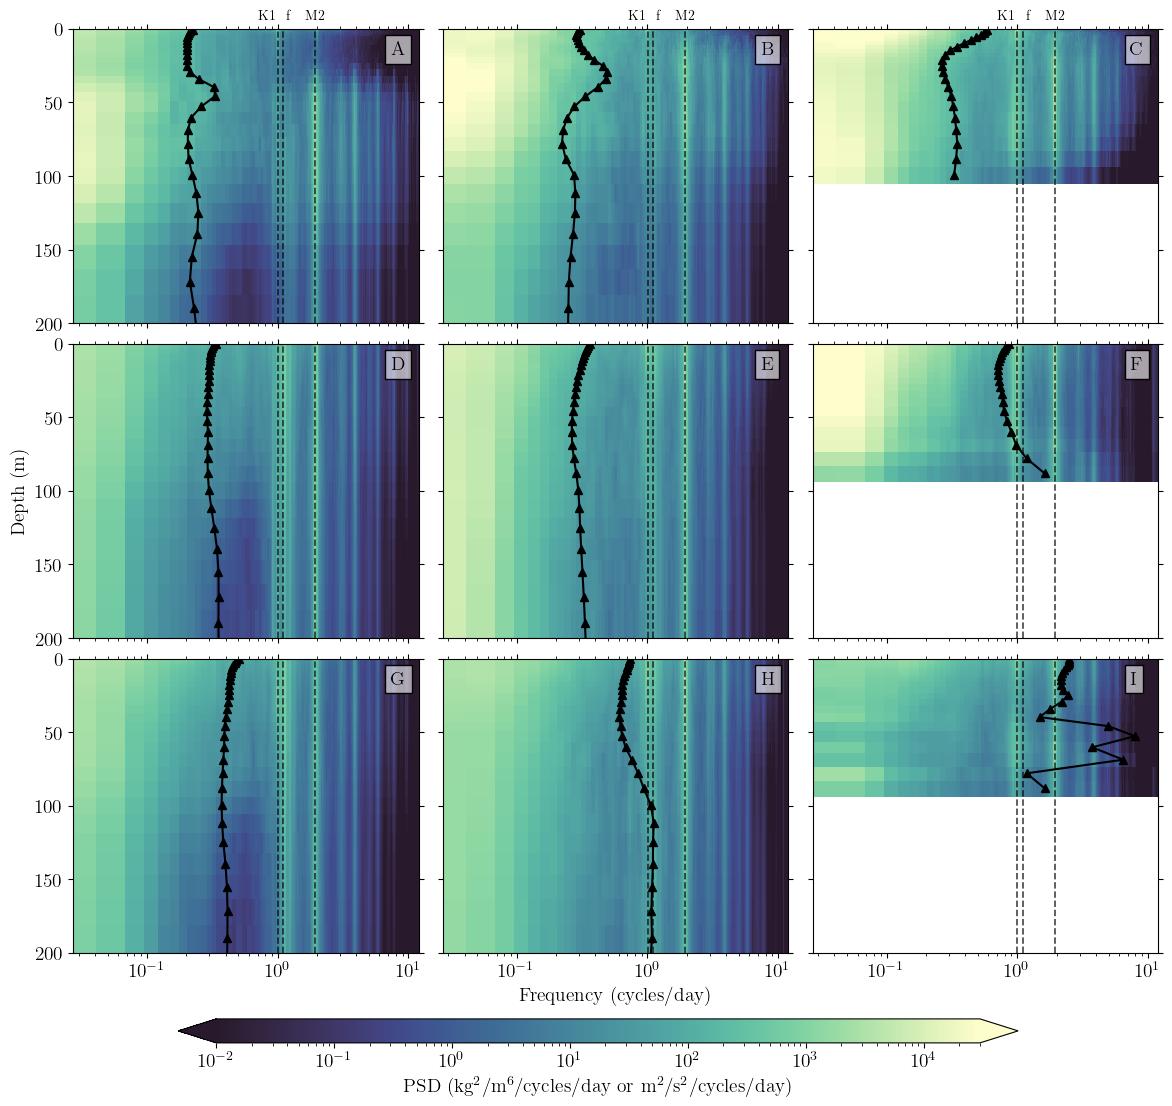

In [14]:
option_data = 'model'

# Set colormap and levels
cmap = cmocean.cm.deep_r

# Define logarithmic normalization
norm = mcolors.LogNorm(vmin=1e-2, vmax=3e4)

# Set the frequency and depth grid for the model and observations
F_m, D_m = np.meshgrid(f_cpd, depth_m)
F, D = np.meshgrid(f1_rho * (86400), depth1)
F_adcp, D_adcp = np.meshgrid(f1_rho * (86400), depth1_adcp)

# Create figure
fig, axes = plt.subplots(3,3,figsize=(14, 12))
ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9 = axes.flatten()

#--- Subplot 1 ---#  

# Plot CCE1 potential density spectrogram overlayed with decorrelation frequency markers
if option_data == 'model': 

    pc = ax1.pcolormesh(F_m,D_m,S1_rho_m.T,cmap=cmap,shading='auto',norm=norm)
    ax1.plot(fd1_rho_m, depth_m, 'k^-', markersize=6)

else: 

    pc = ax1.pcolormesh(F,D,S1_rho.T,cmap=cmap,shading='auto', norm=norm)
    ax1.plot(fd1_rho, depth1, 'k^-', markersize=6)

# Plot the inertial and tidal frequency lines 
ax1.axvline(f1_i, color='k', linestyle='--', alpha=0.7, linewidth=1.25)
ax1.axvline(f_m2, color='k', linestyle='--', alpha=0.7, linewidth=1.25)
ax1.axvline(f_k1, color='k', linestyle='--', alpha=0.7, linewidth=1.25)

# Set figure attributes
ax1.set_xlim(f_cpd[1],f_cpd[-1])
ax1.set_ylim(depth_lim[0],depth_lim[1])
ax1.invert_yaxis() 
ax1.set_xscale('log')
ax1.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=False, labeltop=False,
            direction='out', which='both', length=3.5)
ax1.tick_params(which='major', length=3.5)
ax1.tick_params(which='minor', length=2.5)

#--- Subplot 2 ---#  

if option_data == 'model': 

    pc = ax2.pcolormesh(F_m,D_m,S2_rho_m.T,cmap=cmap,shading='auto',norm=norm)
    ax2.plot(fd2_rho_m, depth_m, 'k^-', markersize=6)

else:

    ax2.pcolormesh(F,D,S2_rho.T,cmap=cmap,shading='auto')
    ax2.plot(fd2_rho, depth1, 'k^-', markersize=6)

# Plot the inertial and tidal frequency lines 
ax2.axvline(f1_i, color='k', linestyle='--', alpha=0.7, linewidth=1.25)
ax2.axvline(f_m2, color='k', linestyle='--', alpha=0.7, linewidth=1.25)
ax2.axvline(f_k1, color='k', linestyle='--', alpha=0.7, linewidth=1.25)

# Set figure attributes
ax2.set_xlim(f_cpd[1],f_cpd[-1])
ax2.set_ylim(depth_lim[0],depth_lim[1])
ax2.invert_yaxis() 
ax2.set_yticklabels([])
ax2.set_xscale('log')
ax2.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=False, labeltop=False,
            direction='out', which='both', length=3.5)
ax2.tick_params(which='major', length=3.5)
ax2.tick_params(which='minor', length=2.5)

#--- Subplot 3 ---#  

if option_data == 'model': 

    pc = ax3.pcolormesh(F_m,D_m,S3_rho_m.T,cmap=cmap,shading='auto',norm=norm)
    ax3.plot(fd3_rho_m, depth_m, 'k^-', markersize=6)

    # Plot the inertial and tidal frequency lines 
    ax3.axvline(f1_i, color='k', linestyle='--', alpha=0.7, linewidth=1.25)
    ax3.axvline(f_m2, color='k', linestyle='--', alpha=0.7, linewidth=1.25)
    ax3.axvline(f_k1, color='k', linestyle='--', alpha=0.7, linewidth=1.25)

    # Set figure attributes
    ax3.set_xlim(f_cpd[1],f_cpd[-1])
    ax3.set_ylim(depth_lim[0],depth_lim[1])
    ax3.invert_yaxis() 
    ax3.set_yticklabels([])
    ax3.set_xscale('log')
    ax3.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=False, labeltop=False,
            direction='out', which='both', length=3.5)
    ax3.tick_params(which='major', length=3.5)
    ax3.tick_params(which='minor', length=2.5)

else: 

    ax3.axis('off')

#--- Subplot 4 ---#  

# Plot CCE1 potential density spectrogram overlayed with decorrelation frequency markers
if option_data == 'model': 

    pc = ax4.pcolormesh(F_m,D_m,S1_u_m.T,cmap=cmap,shading='auto',norm=norm)
    ax4.plot(fd1_u_m, depth_m, 'k^-', markersize=6)

# else: 

    # pc = ax4.pcolormesh(F_adcp,D_adcp,S1_u.T,cmap=cmap,shading='auto', norm=norm)
    # ax4.plot(fd1_u, depth1_adcp, 'k^-', markersize=6)

# Plot the inertial and tidal frequency lines 
ax4.axvline(f1_i, color='k', linestyle='--', alpha=0.7, linewidth=1.25)
ax4.axvline(f_m2, color='k', linestyle='--', alpha=0.7, linewidth=1.25)
ax4.axvline(f_k1, color='k', linestyle='--', alpha=0.7, linewidth=1.25)

# Set figure attributes
ax4.set_ylabel('Depth (m)')
ax4.set_xlim(f_cpd[1],f_cpd[-1])
ax4.set_ylim(depth_lim[0],depth_lim[1])
ax4.invert_yaxis() 
ax4.set_xscale('log')
ax4.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=False, labeltop=False,
            direction='out', which='both', length=3.5)
ax4.tick_params(which='major', length=3.5)
ax4.tick_params(which='minor', length=2.5)

#--- Subplot 5 ---#  

if option_data == 'model': 

    pc = ax5.pcolormesh(F_m,D_m,S2_u_m.T,cmap=cmap,shading='auto',norm=norm)
    ax5.plot(fd2_u_m, depth_m, 'k^-', markersize=6)

# else:

    # ax5.pcolormesh(F_adcp,D_adcp,S2_u.T,cmap=cmap,shading='auto')
    # ax5.plot(fd2_u, depth1_adcp, 'k^-', markersize=6)

# Plot the inertial and tidal frequency lines 
ax5.axvline(f1_i, color='k', linestyle='--', alpha=0.7, linewidth=1.25)
ax5.axvline(f_m2, color='k', linestyle='--', alpha=0.7, linewidth=1.25)
ax5.axvline(f_k1, color='k', linestyle='--', alpha=0.7, linewidth=1.25)

# Set figure attributes
ax5.set_xlim(f_cpd[1],f_cpd[-1])
ax5.set_ylim(depth_lim[0],depth_lim[1])
ax5.invert_yaxis() 
ax5.set_yticklabels([])
ax5.set_xscale('log')
ax5.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=False, labeltop=False,
            direction='out', which='both', length=3.5)
ax5.tick_params(which='major', length=3.5)
ax5.tick_params(which='minor', length=2.5)

#--- Subplot 6 ---#  

if option_data == 'model': 

    pc = ax6.pcolormesh(F_m,D_m,S3_u_m.T,cmap=cmap,shading='auto',norm=norm)
    ax6.plot(fd3_u_m, depth_m, 'k^-', markersize=6)

    # Plot the inertial and tidal frequency lines 
    ax6.axvline(f1_i, color='k', linestyle='--', alpha=0.7, linewidth=1.25)
    ax6.axvline(f_m2, color='k', linestyle='--', alpha=0.7, linewidth=1.25)
    ax6.axvline(f_k1, color='k', linestyle='--', alpha=0.7, linewidth=1.25)

    # Set figure attributes
    ax6.set_xlim(f_cpd[1],f_cpd[-1])
    ax6.set_ylim(depth_lim[0],depth_lim[1])
    ax6.invert_yaxis() 
    ax6.set_yticklabels([])
    ax6.set_xscale('log')
    ax6.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=False, labeltop=False,
            direction='out', which='both', length=3.5)
    ax6.tick_params(which='major', length=3.5)
    ax6.tick_params(which='minor', length=2.5)
    
else: 

    ax6.axis('off')

#--- Subplot 7 ---#  

# Plot CCE1 potential density spectrogram overlayed with decorrelation frequency markers
if option_data == 'model': 

    pc = ax7.pcolormesh(F_m,D_m,S1_v_m.T,cmap=cmap,shading='auto',norm=norm)
    ax7.plot(fd1_v_m, depth_m, 'k^-', markersize=6)

# else: 

    # pc = ax7.pcolormesh(F_adcp,D_adcp,S1_v.T,cmap=cmap,shading='auto', norm=norm)
    # ax7.plot(fd1_v, depth1_adcp, 'k^-', markersize=6)

# Plot the inertial and tidal frequency lines 
ax7.axvline(f1_i, color='k', linestyle='--', alpha=0.7, linewidth=1.25)
ax7.axvline(f_m2, color='k', linestyle='--', alpha=0.7, linewidth=1.25)
ax7.axvline(f_k1, color='k', linestyle='--', alpha=0.7, linewidth=1.25)

# Set figure attributes
ax7.set_xlim(f_cpd[1],f_cpd[-1])
ax7.set_ylim(depth_lim[0],depth_lim[1])
ax7.invert_yaxis() 
ax7.set_xscale('log')
ax7.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
            direction='out', which='both', length=3.5)
ax7.tick_params(which='major', length=3.5)
ax7.tick_params(which='minor', length=2.5)

#--- Subplot 8 ---#  

if option_data == 'model': 

    pc = ax8.pcolormesh(F_m,D_m,S2_v_m.T,cmap=cmap,shading='auto',norm=norm)
    ax8.plot(fd2_v_m, depth_m, 'k^-', markersize=6)

# else:

    # ax8.pcolormesh(F_adcp,D_adcp,S2_v.T,cmap=cmap,shading='auto')
    # ax8.plot(fd2_v, depth1_adcp, 'k^-', markersize=6)

# Plot the inertial and tidal frequency lines 
ax8.axvline(f1_i, color='k', linestyle='--', alpha=0.7, linewidth=1.25)
ax8.axvline(f_m2, color='k', linestyle='--', alpha=0.7, linewidth=1.25)
ax8.axvline(f_k1, color='k', linestyle='--', alpha=0.7, linewidth=1.25)

# Set figure attributes
ax8.set_xlabel(r'Frequency (cycles/day)')
ax8.set_xlim(f_cpd[1],f_cpd[-1])
ax8.set_ylim(depth_lim[0],depth_lim[1])
ax8.invert_yaxis() 
ax8.set_yticklabels([])
ax8.set_xscale('log')
ax8.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
            direction='out', which='both', length=3.5)
ax8.tick_params(which='major', length=3.5)
ax8.tick_params(which='minor', length=2.5)

#--- Subplot 9 ---#  

if option_data == 'model': 

    pc = ax9.pcolormesh(F_m,D_m,S3_v_m.T,cmap=cmap,shading='auto',norm=norm)
    ax9.plot(fd3_v_m, depth_m, 'k^-', markersize=6)

    # Plot the inertial and tidal frequency lines 
    ax9.axvline(f1_i, color='k', linestyle='--', alpha=0.7, linewidth=1.25)
    ax9.axvline(f_m2, color='k', linestyle='--', alpha=0.7, linewidth=1.25)
    ax9.axvline(f_k1, color='k', linestyle='--', alpha=0.7, linewidth=1.25)

    # Set figure attributes
    ax9.set_xlim(f_cpd[1],f_cpd[-1])
    ax9.set_ylim(depth_lim[0],depth_lim[1])
    ax9.invert_yaxis() 
    ax9.set_yticklabels([])
    ax9.set_xscale('log')
    ax9.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
                direction='out', which='both', length=3.5)
    ax9.tick_params(which='major', length=3.5)
    ax9.tick_params(which='minor', length=2.5)

else: 

    ax9.axis('off')

# Set color bar
cax = fig.add_axes([0.20, 0.035, 0.6, 0.02])  # [left, bottom, width, height]
cbar = fig.colorbar(pc, cax=cax, orientation='horizontal', extend='both') 
cbar.set_label(r'PSD (kg$^2$/m$^6$/cycles/day or m$^2$/s$^2$/cycles/day)')

# Label each subplot
pos = [0.92, 0.96]
add_corner_label(ax1, pos, 'A', fontsize = fontsize)
add_corner_label(ax2, pos, 'B', fontsize = fontsize)
add_corner_label(ax3, pos, 'C', fontsize = fontsize)
add_corner_label(ax4, pos, 'D', fontsize = fontsize)
add_corner_label(ax5, pos, 'E', fontsize = fontsize)
add_corner_label(ax6, pos, 'F', fontsize = fontsize)
add_corner_label(ax7, pos, 'G', fontsize = fontsize)
add_corner_label(ax8, pos, 'H', fontsize = fontsize)
add_corner_label(ax9, pos, 'I', fontsize = fontsize)

# Example text positions for top row
ax1.text(f1_i + 0.1, depth_lim[0] - 5, 'f', ha='center', va='bottom', fontsize=10)
ax1.text(f_m2, depth_lim[0] - 5, 'M2', ha='center', va='bottom', fontsize=10)
ax1.text(f_k1 - 0.18, depth_lim[0] - 5, 'K1', ha='center', va='bottom', fontsize=10)

ax2.text(f1_i + 0.1, depth_lim[0] - 5, 'f', ha='center', va='bottom', fontsize=10)
ax2.text(f_m2, depth_lim[0] - 5, 'M2', ha='center', va='bottom', fontsize=10)
ax2.text(f_k1 - 0.18, depth_lim[0] - 5, 'K1', ha='center', va='bottom', fontsize=10)

ax3.text(f1_i + 0.1, depth_lim[0] - 5, 'f', ha='center', va='bottom', fontsize=10)
ax3.text(f_m2, depth_lim[0] - 5, 'M2', ha='center', va='bottom', fontsize=10)
ax3.text(f_k1 - 0.18, depth_lim[0] - 5, 'K1', ha='center', va='bottom', fontsize=10)

# Display figure
plt.subplots_adjust(hspace=0.07, wspace=0.07)
plt.show()

Compute mixed layer depth from potential density 

In [19]:
np.shape(meanRho_m)

(3, 90)

In [22]:
mld_density1 = compute_mld(depth1, density=meanRho1,
                          method='threshold', variable='density')
mld_density2 = compute_mld(depth2, density=meanRho2,
                          method='threshold', variable='density')

mld_density1_m = compute_mld(depth_m, density=meanRho_m[0,:],
                          method='threshold', variable='density')
mld_density2_m = compute_mld(depth_m, density=meanRho_m[1,:],
                          method='threshold', variable='density')
mld_density3_m = compute_mld(depth_m, density=meanRho_m[2,:],
                          method='threshold', variable='density')

print("MLD CCE1 (obs):", mld_density1)
print("MLD CCE2 (obs):", mld_density2)

print("MLD CCE1 (model):", mld_density1_m)
print("MLD CCE2 (model):", mld_density2_m)
print("MLD CCE3 (model):", mld_density3_m)

MLD CCE1 (obs): 25
MLD CCE2 (obs): 15
MLD CCE1 (model): 34.24
MLD CCE2 (model): 14.68
MLD CCE3 (model): 12.01
